In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("Libraries imported.")

Libraries imported.


In [4]:
data = fetch_california_housing()
X_full = data.data        # 8 features
y_full = data.target      # house prices

# Use only 1 feature (average rooms) so we can plot a line
# Column index 2 = AveRooms
X = X_full[:, 2]
y = y_full

# Normalize X and y (subtract mean, divide by std)
# This is required for gradient descent to work properly
X_mean, X_std = X.mean(), X.std()
y_mean, y_std = y.mean(), y.std()

X_norm = (X - X_mean) / X_std
y_norm = (y - y_mean) / y_std

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_norm, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 16512
Testing samples:  4128


In [6]:
class LinearRegressionScratch:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.m = 0  # slope (weight)
        self.c = 0  # intercept (bias)

    def fit(self, X, y):
        n = len(y)
        for _ in range(self.iterations):
            y_pred = self.m * X + self.c
            error = y - y_pred
            # Gradients
            dm = (-2 / n) * np.sum(X * error)
            dc = (-2 / n) * np.sum(error)
            # Update weights
            self.m -= self.lr * dm
            self.c -= self.lr * dc

    def predict(self, X):
        return self.m * X + self.c


# Train the scratch model
scratch_model = LinearRegressionScratch(learning_rate=0.01, iterations=1000)
scratch_model.fit(X_train, y_train)

print(f"Scratch model — slope: {scratch_model.m:.4f}, intercept: {scratch_model.c:.4f}")

Scratch model — slope: 0.1646, intercept: 0.0025


In [7]:
sklearn_model = LinearRegression()
sklearn_model.fit(X_train.reshape(-1, 1), y_train)

print(f"Sklearn model — slope: {sklearn_model.coef_[0]:.4f}, intercept: {sklearn_model.intercept_:.4f}")


Sklearn model — slope: 0.1646, intercept: 0.0025


In [8]:
y_pred_scratch = scratch_model.predict(X_test)
y_pred_sklearn = sklearn_model.predict(X_test.reshape(-1, 1))

# Scratch metrics
mse_s  = mean_squared_error(y_test, y_pred_scratch)
mae_s  = mean_absolute_error(y_test, y_pred_scratch)
r2_s   = r2_score(y_test, y_pred_scratch)

# Sklearn metrics
mse_sk = mean_squared_error(y_test, y_pred_sklearn)
mae_sk = mean_absolute_error(y_test, y_pred_sklearn)
r2_sk  = r2_score(y_test, y_pred_sklearn)

print("=" * 45)
print(f"{'Metric':<10} {'Scratch':>15} {'Sklearn':>15}")
print("=" * 45)
print(f"{'MSE':<10} {mse_s:>15.4f} {mse_sk:>15.4f}")
print(f"{'MAE':<10} {mae_s:>15.4f} {mae_sk:>15.4f}")
print(f"{'R²':<10} {r2_s:>15.4f} {r2_sk:>15.4f}")
print("=" * 45)

Metric             Scratch         Sklearn
MSE                 0.9705          0.9705
MAE                 0.7705          0.7705
R²                  0.0138          0.0138


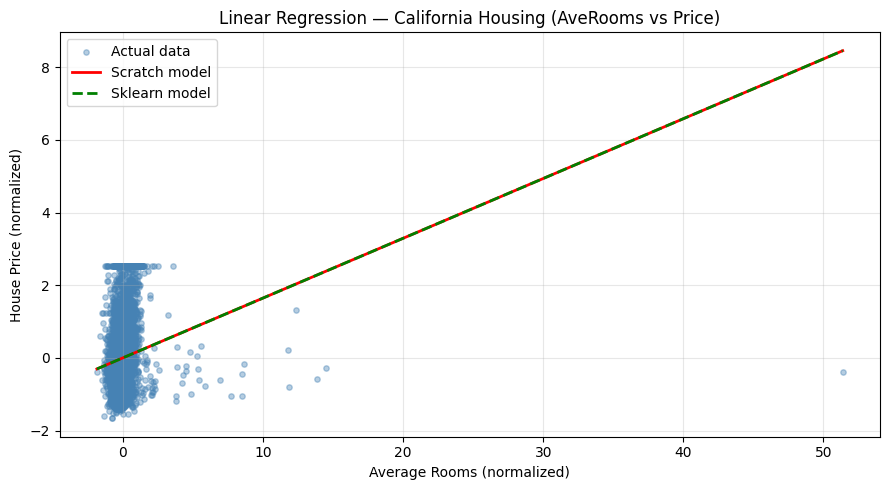

In [9]:
x_line = np.linspace(X_test.min(), X_test.max(), 100)

plt.figure(figsize=(9, 5))
plt.scatter(X_test, y_test, color='steelblue', alpha=0.4, s=15, label='Actual data')
plt.plot(x_line, scratch_model.predict(x_line), color='red',    linewidth=2, label='Scratch model')
plt.plot(x_line, sklearn_model.predict(x_line.reshape(-1, 1)), color='green', linewidth=2, linestyle='--', label='Sklearn model')
plt.title("Linear Regression — California Housing (AveRooms vs Price)")
plt.xlabel("Average Rooms (normalized)")
plt.ylabel("House Price (normalized)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:
print("""
Comparison:
Both models produce very similar results on the California Housing dataset.
The scratch model implements gradient descent manually — it iteratively
nudges the slope and intercept to minimize Mean Squared Error.
Sklearn's LinearRegression uses the Ordinary Least Squares method which
solves for the optimal weights directly using linear algebra, so it is
slightly faster and marginally more precise.
The close R² scores between the two confirm that gradient descent, when
properly tuned with normalization, converges to nearly the same solution.
""")



Comparison:
Both models produce very similar results on the California Housing dataset.
The scratch model implements gradient descent manually — it iteratively 
nudges the slope and intercept to minimize Mean Squared Error.
Sklearn's LinearRegression uses the Ordinary Least Squares method which 
solves for the optimal weights directly using linear algebra, so it is 
slightly faster and marginally more precise.
The close R² scores between the two confirm that gradient descent, when 
properly tuned with normalization, converges to nearly the same solution.

